<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-39-confusion-matrix-metrics?scriptVersionId=345392592" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a0a1a 0%, #1a1035 50%, #0d1a2e 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #2d2060;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 39</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">📊 Confusion Matrix &amp; Classification Metrics</h1>
  <p style="color: #a89dd0; font-size: 16px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">Why accuracy alone lies to you — mastering Precision, Recall, F1 Score, and the Confusion Matrix to build classifiers you can actually trust.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #2d2060; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a78bfa; font-size: 22px; font-weight: 700;">2 Datasets</div>
      <div style="color: #a89dd0; font-size: 12px; margin-top: 2px;">Heart Disease + MNIST</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #2d2060; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a78bfa; font-size: 22px; font-weight: 700;">4 Metrics</div>
      <div style="color: #a89dd0; font-size: 12px; margin-top: 2px;">Accuracy · Precision · Recall · F1</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #2d2060; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a78bfa; font-size: 22px; font-weight: 700;">Binary + Multi</div>
      <div style="color: #a89dd0; font-size: 12px; margin-top: 2px;">Both classification types</div>
    </div>
  </div>
</div>

<div style="background: #0d0d20; border-left: 5px solid #7c3aed; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #2d2060; border-left: 5px solid #7c3aed;">
  <h2 style="color: #a78bfa; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #818cf8; line-height: 2.1; font-size: 14px;">
    <li><a href='#imports' style='color: #818cf8; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#data' style='color: #818cf8; text-decoration: none;'>Dataset — Heart Disease (Binary Classification)</a></li>
    <li><a href='#models' style='color: #818cf8; text-decoration: none;'>Training — Logistic Regression vs Decision Tree</a></li>
    <li><a href='#accuracy' style='color: #818cf8; text-decoration: none;'>Accuracy Score — And Why It Can Mislead</a></li>
    <li><a href='#confusion' style='color: #818cf8; text-decoration: none;'>Confusion Matrix — Reading TP, FP, FN, TN</a></li>
    <li><a href='#errors' style='color: #818cf8; text-decoration: none;'>Type 1 &amp; Type 2 Errors</a></li>
    <li><a href='#metrics' style='color: #818cf8; text-decoration: none;'>Precision, Recall &amp; F1 Score</a></li>
    <li><a href='#averaging' style='color: #818cf8; text-decoration: none;'>Averaging Strategies — None, Macro, Weighted</a></li>
    <li><a href='#multiclass' style='color: #818cf8; text-decoration: none;'>Multi-class Classification — MNIST Digits</a></li>
    <li><a href='#report' style='color: #818cf8; text-decoration: none;'>Classification Report</a></li>
    <li><a href='#summary' style='color: #818cf8; text-decoration: none;'>Summary &amp; When to Use Each Metric</a></li>
  </ol>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score,
    f1_score, classification_report,
    ConfusionMatrixDisplay
)

<a id='data'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Dataset — Heart Disease (Binary Classification)</h2>
</div>

The **UCI Heart Disease dataset** contains 303 patients with 13 clinical features. The target is binary — `1` means heart disease present, `0` means absent. This is a real medical classification problem where **the cost of errors is asymmetric** — missing a sick patient (false negative) is far more dangerous than a false alarm (false positive).

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 10px; padding: 18px 24px; margin: 16px 0; font-size: 13px;">
  <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 14px; text-align: center;">
    <div><div style="color: #a78bfa; font-size: 22px; font-weight: 700;">303</div><div style="color: #a89dd0;">patients</div></div>
    <div><div style="color: #a78bfa; font-size: 22px; font-weight: 700;">13</div><div style="color: #a89dd0;">features</div></div>
    <div><div style="color: #a78bfa; font-size: 22px; font-weight: 700;">2</div><div style="color: #a89dd0;">classes (binary)</div></div>
    <div><div style="color: #a78bfa; font-size: 22px; font-weight: 700;">Medical</div><div style="color: #a89dd0;">real-world stakes</div></div>
  </div>
</div>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mragpavank/heart-diseaseuci/heart.csv")

print(f"Shape   : {df.shape}")
print(f"Nulls   : {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['target'].value_counts().rename({0: 'No Disease', 1: 'Disease'}).to_string())

df.head()

Shape   : (303, 14)
Nulls   : 0

Target distribution:
target
Disease       165
No Disease    138


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

Train : (227, 13)  |  Test : (76, 13)


<a id='models'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Training — Logistic Regression vs Decision Tree</h2>
</div>

We train two classifiers to compare their performance across multiple metrics. Comparing models on a single metric (accuracy) is misleading — we need the full picture.

In [4]:
clf1 = LogisticRegression(max_iter=1000)
clf2 = DecisionTreeClassifier(random_state=42)

clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred1 = clf1.predict(X_test)   # Logistic Regression predictions
y_pred2 = clf2.predict(X_test)   # Decision Tree predictions

print("Both models trained successfully.")

Both models trained successfully.


<a id='accuracy'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Accuracy Score — And Why It Can Mislead</h2>
</div>

**Accuracy** = (Correct predictions) / (Total predictions). It's the most intuitive metric — and the most dangerous one to use alone.

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 12px; padding: 20px 26px; margin: 16px 0;">
  <div style="color: #a89dd0; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">When Accuracy Fails — Classic Example</div>
  <div style="color: #e2e0f0; font-size: 14px; line-height: 1.8;">
    Imagine a cancer screening model on 1000 patients where only 10 have cancer.<br/>
    A model that <strong style='color:#e74c3c;'>always predicts No Cancer</strong> gets <strong style='color:#e74c3c;'>99% accuracy</strong> — but it's completely useless.<br/>
    It misses all 10 cancer patients. <strong style='color:#a78bfa;'>Accuracy hid a catastrophic failure.</strong>
  </div>
</div>

<div style="display: flex; gap: 14px; margin: 16px 0;">
  <div style="flex: 1; background: #0d0d20; border: 1px solid #2d2060; border-top: 2px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 4px;">⚠️ Imbalanced classes</div>
    <div style="color: #a89dd0; font-size: 13px;">Rare events (fraud, disease) make accuracy trivially high by always predicting the majority class</div>
  </div>
  <div style="flex: 1; background: #0d0d20; border: 1px solid #2d2060; border-top: 2px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 4px;">⚠️ Unequal error costs</div>
    <div style="color: #a89dd0; font-size: 13px;">Missing a sick patient costs more than a false alarm — accuracy treats both errors identically</div>
  </div>
  <div style="flex: 1; background: #0d0d20; border: 1px solid #2d2060; border-top: 2px solid #a78bfa; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #a78bfa; font-weight: 700; font-size: 13px; margin-bottom: 4px;">✅ Solution</div>
    <div style="color: #a89dd0; font-size: 13px;">Use Confusion Matrix, Precision, Recall, and F1 to understand <em>which</em> errors your model makes</div>
  </div>
</div>

In [5]:
acc1 = accuracy_score(y_test, y_pred1)
acc2 = accuracy_score(y_test, y_pred2)

print(f"Logistic Regression accuracy : {acc1:.4f}  ({acc1*100:.1f}%)")
print(f"Decision Tree accuracy        : {acc2:.4f}  ({acc2*100:.1f}%)")
print()
print("👆 Logistic Regression looks clearly better — but let's dig deeper.")

Logistic Regression accuracy : 0.8947  (89.5%)
Decision Tree accuracy        : 0.8026  (80.3%)

👆 Logistic Regression looks clearly better — but let's dig deeper.


<a id='confusion'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Confusion Matrix — Reading TP, FP, FN, TN</h2>
</div>

A confusion matrix shows the **full breakdown of every prediction** — not just whether the model was right or wrong, but which type of right and which type of wrong.

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 12px; padding: 20px 28px; margin: 16px 0;">
  <div style="color: #a89dd0; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">Confusion Matrix — 2×2 Layout (Binary)</div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; max-width: 440px;">
    <div style="background: rgba(46,204,113,0.15); border: 1px solid #2ecc71; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #2ecc71; font-weight: 800; font-size: 16px;">TP</div>
      <div style="color: #e2e0f0; font-size: 12px; margin-top: 4px;">True Positive<br/>Predicted 1, Actually 1 ✅</div>
    </div>
    <div style="background: rgba(231,76,60,0.15); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #e74c3c; font-weight: 800; font-size: 16px;">FP</div>
      <div style="color: #e2e0f0; font-size: 12px; margin-top: 4px;">False Positive<br/>Predicted 1, Actually 0 ❌<br/><em>Type I Error</em></div>
    </div>
    <div style="background: rgba(243,156,18,0.15); border: 1px solid #f39c12; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #f39c12; font-weight: 800; font-size: 16px;">FN</div>
      <div style="color: #e2e0f0; font-size: 12px; margin-top: 4px;">False Negative<br/>Predicted 0, Actually 1 ❌<br/><em>Type II Error</em></div>
    </div>
    <div style="background: rgba(46,204,113,0.15); border: 1px solid #2ecc71; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #2ecc71; font-weight: 800; font-size: 16px;">TN</div>
      <div style="color: #e2e0f0; font-size: 12px; margin-top: 4px;">True Negative<br/>Predicted 0, Actually 0 ✅</div>
    </div>
  </div>
  <div style="color: #a89dd0; font-size: 12px; margin-top: 14px;">Layout: rows = actual labels, columns = predicted labels</div>
</div>

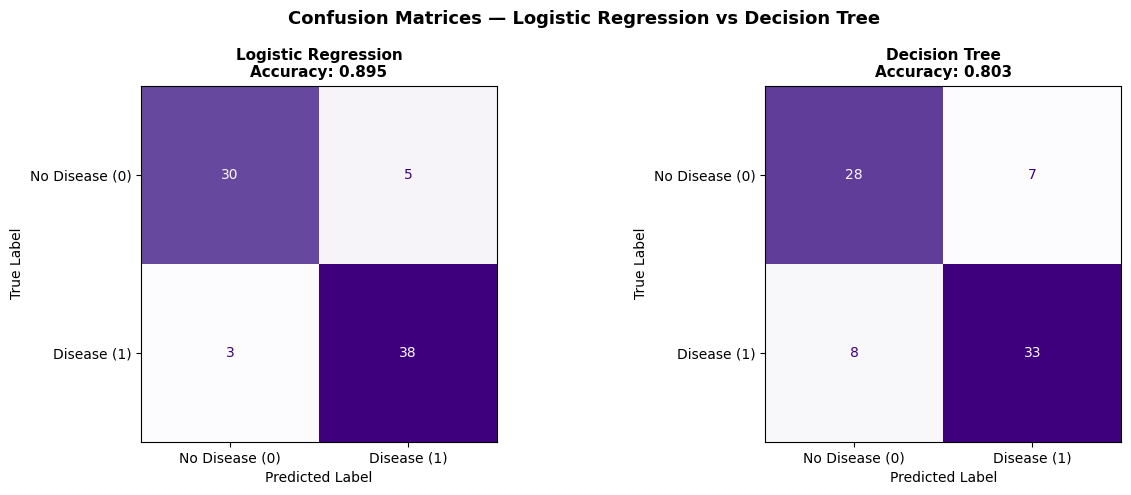

Logistic Regression Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           30            5
Actual 1            3           38 

Decision Tree Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           28            7
Actual 1            8           33


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Logistic Regression vs Decision Tree',
             fontsize=13, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred1, y_pred2],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Disease (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

# Also print as DataFrame for reference
print("Logistic Regression Confusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred1),
      index=['Actual 0', 'Actual 1'],
      columns=['Predicted 0', 'Predicted 1']), "\n")

print("Decision Tree Confusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred2),
      index=['Actual 0', 'Actual 1'],
      columns=['Predicted 0', 'Predicted 1']))

In [7]:
# Side-by-side prediction sample
result = pd.DataFrame({
    'Actual':               y_test.values,
    'Logistic Regression':  y_pred1,
    'Decision Tree':        y_pred2
}, index=y_test.index)

result['LR Correct?']  = result['Actual'] == result['Logistic Regression']
result['DT Correct?']  = result['Actual'] == result['Decision Tree']

result.sample(10, random_state=1)

,Actual,Logistic Regression,Decision Tree,LR Correct?,DT Correct?
279,0,0,0,True,True
249,0,0,1,True,False
5,1,1,1,True,True
22,1,1,1,True,True
204,0,0,0,True,True
254,0,1,1,False,False
92,1,1,1,True,True
42,1,0,0,False,False
17,1,1,1,True,True
132,1,1,1,True,True


<a id='errors'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Type I &amp; Type II Errors — Why Error Type Matters</h2>
</div>

Not all mistakes are equal. The confusion matrix reveals **which kind of errors** your model makes — and in medical, legal, or safety contexts, the two types have very different consequences.

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 20px 0;">
  <div style="background: #0d0d20; border: 1px solid #e74c3c; border-radius: 10px; padding: 20px;">
    <div style="color: #e74c3c; font-size: 14px; font-weight: 700; margin-bottom: 10px;">🔴 Type I Error — False Positive (FP)</div>
    <div style="color: #a89dd0; font-size: 13px; line-height: 1.7;">
      Model predicts <strong style='color:#e2e0f0;'>positive</strong> when the truth is <strong style='color:#e2e0f0;'>negative</strong>.<br/><br/>
      <strong>Heart disease:</strong> Telling a healthy patient they have heart disease → unnecessary stress, tests, treatment<br/><br/>
      <strong>Spam filter:</strong> Marking a legitimate email as spam → missing an important message<br/><br/>
      <em>Metric that catches this: <strong style='color:#a78bfa;'>Precision</strong></em>
    </div>
  </div>
  <div style="background: #0d0d20; border: 1px solid #f39c12; border-radius: 10px; padding: 20px;">
    <div style="color: #f39c12; font-size: 14px; font-weight: 700; margin-bottom: 10px;">🟡 Type II Error — False Negative (FN)</div>
    <div style="color: #a89dd0; font-size: 13px; line-height: 1.7;">
      Model predicts <strong style='color:#e2e0f0;'>negative</strong> when the truth is <strong style='color:#e2e0f0;'>positive</strong>.<br/><br/>
      <strong>Heart disease:</strong> Missing a sick patient who actually has heart disease → delayed treatment, death risk<br/><br/>
      <strong>Fraud detection:</strong> Flagging a real fraud as legitimate → financial loss<br/><br/>
      <em>Metric that catches this: <strong style='color:#a78bfa;'>Recall</strong></em>
    </div>
  </div>
</div>

<div style="background: #13102a; border: 1px solid #2d2060; border-radius: 8px; padding: 14px 18px; margin: 14px 0; font-size: 13px; color: #a89dd0;">
  <strong style="color: #a78bfa;">💡 In our heart disease problem:</strong> A False Negative (missing a sick patient) is far more dangerous than a False Positive (extra tests for a healthy patient). This means <strong style='color:#e2e0f0;'>Recall is more important than Precision</strong> here — and accuracy alone hides this entirely.
</div>

<a id='metrics'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Precision, Recall &amp; F1 Score</h2>
</div>

Each metric answers a different question about your model's behaviour:

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 12px; padding: 22px 28px; margin: 16px 0;">
  <div style="display: flex; flex-direction: column; gap: 16px;">
    <div style="display: flex; gap: 16px; align-items: center;">
      <div style="background: #1e1040; border: 1px solid #7c3aed; border-radius: 8px; padding: 10px 16px; min-width: 110px; text-align: center;">
        <div style="color: #a78bfa; font-weight: 800; font-size: 15px;">Precision</div>
      </div>
      <div>
        <div style="color: #e2e0f0; font-size: 15px; font-family: Georgia, serif;">TP / (TP + FP)</div>
        <div style="color: #a89dd0; font-size: 13px; margin-top: 4px;">"Of all the patients I predicted have disease, what fraction actually do?" — measures <strong style='color:#e2e0f0;'>quality of positive predictions</strong></div>
      </div>
    </div>
    <div style="display: flex; gap: 16px; align-items: center;">
      <div style="background: #1e1040; border: 1px solid #7c3aed; border-radius: 8px; padding: 10px 16px; min-width: 110px; text-align: center;">
        <div style="color: #a78bfa; font-weight: 800; font-size: 15px;">Recall</div>
      </div>
      <div>
        <div style="color: #e2e0f0; font-size: 15px; font-family: Georgia, serif;">TP / (TP + FN)</div>
        <div style="color: #a89dd0; font-size: 13px; margin-top: 4px;">"Of all patients who actually have disease, how many did I catch?" — measures <strong style='color:#e2e0f0;'>coverage of actual positives</strong></div>
      </div>
    </div>
    <div style="display: flex; gap: 16px; align-items: center;">
      <div style="background: #1e1040; border: 1px solid #7c3aed; border-radius: 8px; padding: 10px 16px; min-width: 110px; text-align: center;">
        <div style="color: #a78bfa; font-weight: 800; font-size: 15px;">F1 Score</div>
      </div>
      <div>
        <div style="color: #e2e0f0; font-size: 15px; font-family: Georgia, serif;">2 · (Precision · Recall) / (Precision + Recall)</div>
        <div style="color: #a89dd0; font-size: 13px; margin-top: 4px;">Harmonic mean of Precision and Recall — balances both. Use when you care about <strong style='color:#e2e0f0;'>both false positives and false negatives</strong></div>
      </div>
    </div>
  </div>
</div>

In [8]:
# ── Logistic Regression metrics ────────────────────────────────────────────
print("=" * 50)
print("  LOGISTIC REGRESSION")
print("=" * 50)
cm1 = confusion_matrix(y_test, y_pred1)
tn, fp, fn, tp = cm1.ravel()
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred1):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred1):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred1):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred1):.4f}")

print()

# ── Decision Tree metrics ──────────────────────────────────────────────────
print("=" * 50)
print("  DECISION TREE")
print("=" * 50)
cm2 = confusion_matrix(y_test, y_pred2)
tn2, fp2, fn2, tp2 = cm2.ravel()
print(f"  TP={tp2}  FP={fp2}  FN={fn2}  TN={tn2}")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred2):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred2):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred2):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred2):.4f}")

  LOGISTIC REGRESSION
  TP=38  FP=5  FN=3  TN=30
  Accuracy  : 0.8947
  Precision : 0.8837
  Recall    : 0.9268
  F1 Score  : 0.9048

  DECISION TREE
  TP=33  FP=7  FN=8  TN=28
  Accuracy  : 0.8026
  Precision : 0.8250
  Recall    : 0.8049
  F1 Score  : 0.8148


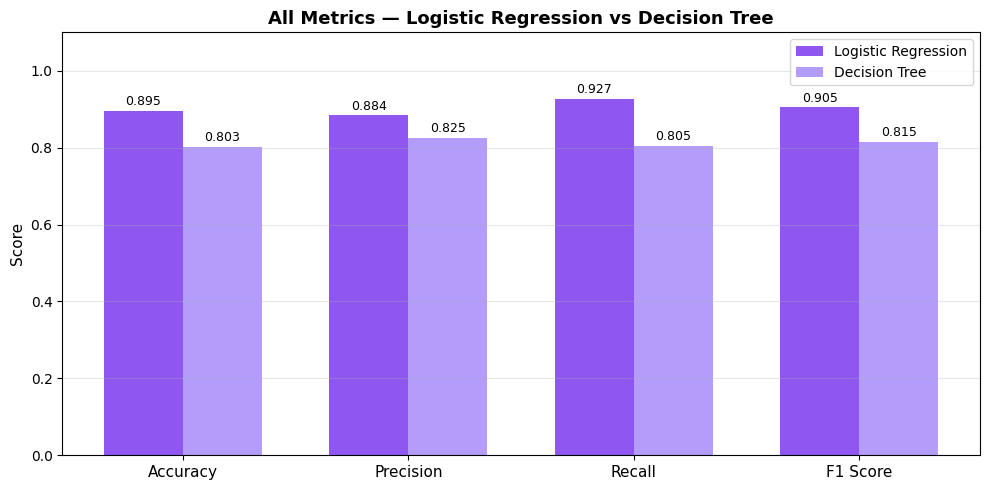

In [9]:
# Visual comparison — radar / bar chart of all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [
    accuracy_score(y_test, y_pred1),
    precision_score(y_test, y_pred1),
    recall_score(y_test, y_pred1),
    f1_score(y_test, y_pred1)
]
dt_scores = [
    accuracy_score(y_test, y_pred2),
    precision_score(y_test, y_pred2),
    recall_score(y_test, y_pred2),
    f1_score(y_test, y_pred2)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#7c3aed', alpha=0.85)
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree',
               color='#a78bfa', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('All Metrics — Logistic Regression vs Decision Tree', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt='%.3f', fontsize=9, padding=2)
ax.bar_label(bars2, fmt='%.3f', fontsize=9, padding=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #0d0d20; border-left: 4px solid #a78bfa; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #a89dd0;">
  <strong style="color: #e2e0f0;">✅ Key takeaway:</strong> Logistic Regression wins on every metric — especially <strong>Recall (0.927)</strong>. This means it catches more actual heart disease cases (fewer dangerous misses). The Decision Tree's Recall is lower, meaning it misses more sick patients — much riskier in a medical context.
</div>

<a id='averaging'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Averaging Strategies — None, Macro &amp; Weighted</h2>
</div>

When there are multiple classes, sklearn needs to know how to combine per-class scores into a single number. There are three strategies:

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 10px; overflow: hidden; margin: 16px 0;">
  <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
    <thead>
      <tr style="background: #1e1040;">
        <th style="padding: 12px 16px; color: #a78bfa; text-align: left;">Strategy</th>
        <th style="padding: 12px 16px; color: #a78bfa; text-align: left;">What it does</th>
        <th style="padding: 12px 16px; color: #a78bfa; text-align: left;">Use when</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #2d2060;">
        <td style="padding: 11px 16px; font-weight: 600; color: #e2e0f0;">None</td>
        <td style="padding: 11px 16px; color: #a89dd0;">Returns score for each class separately (array)</td>
        <td style="padding: 11px 16px; color: #a89dd0;">You need per-class breakdown</td>
      </tr>
      <tr style="border-bottom: 1px solid #2d2060; background: rgba(124,58,237,0.05);">
        <td style="padding: 11px 16px; font-weight: 600; color: #e2e0f0;">macro</td>
        <td style="padding: 11px 16px; color: #a89dd0;">Simple average — treats all classes equally</td>
        <td style="padding: 11px 16px; color: #a89dd0;">Balanced classes, each class equally important</td>
      </tr>
      <tr style="background: rgba(124,58,237,0.05);">
        <td style="padding: 11px 16px; font-weight: 600; color: #e2e0f0;">weighted</td>
        <td style="padding: 11px 16px; color: #a89dd0;">Average weighted by class support (sample count)</td>
        <td style="padding: 11px 16px; color: #a89dd0;">Imbalanced classes, larger classes matter more</td>
      </tr>
    </tbody>
  </table>
</div>

In [10]:
print("── Per-class Precision (average=None) ───────────────────────")
print(f"  Logistic Regression : {precision_score(y_test, y_pred1, average=None).round(4)}")
print(f"  Decision Tree       : {precision_score(y_test, y_pred2, average=None).round(4)}")

print("\n── Per-class Recall (average=None) ──────────────────────────")
print(f"  Logistic Regression : {recall_score(y_test, y_pred1, average=None).round(4)}")
print(f"  Decision Tree       : {recall_score(y_test, y_pred2, average=None).round(4)}")

print("\n── Macro Average (equal class weight) ───────────────────────")
print(f"  Precision LR  : {precision_score(y_test, y_pred1, average='macro'):.4f}")
print(f"  Precision DT  : {precision_score(y_test, y_pred2, average='macro'):.4f}")
print(f"  Recall    LR  : {recall_score(y_test, y_pred1, average='macro'):.4f}")
print(f"  Recall    DT  : {recall_score(y_test, y_pred2, average='macro'):.4f}")

print("\n── Weighted Average (weighted by class size) ─────────────────")
print(f"  Precision LR  : {precision_score(y_test, y_pred1, average='weighted'):.4f}")
print(f"  Precision DT  : {precision_score(y_test, y_pred2, average='weighted'):.4f}")
print(f"  Recall    LR  : {recall_score(y_test, y_pred1, average='weighted'):.4f}")
print(f"  Recall    DT  : {recall_score(y_test, y_pred2, average='weighted'):.4f}")

── Per-class Precision (average=None) ───────────────────────
  Logistic Regression : [0.9091 0.8837]
  Decision Tree       : [0.7778 0.825 ]

── Per-class Recall (average=None) ──────────────────────────
  Logistic Regression : [0.8571 0.9268]
  Decision Tree       : [0.8    0.8049]

── Macro Average (equal class weight) ───────────────────────
  Precision LR  : 0.8964
  Precision DT  : 0.8014
  Recall    LR  : 0.8920
  Recall    DT  : 0.8024

── Weighted Average (weighted by class size) ─────────────────
  Precision LR  : 0.8954
  Precision DT  : 0.8033
  Recall    LR  : 0.8947
  Recall    DT  : 0.8026


<a id='multiclass'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Multi-class Classification — MNIST Handwritten Digits</h2>
</div>

Everything we've discussed for binary classification extends naturally to **10 classes**. The confusion matrix grows to 10×10 — each row represents an actual digit, each column a predicted digit. Off-diagonal cells reveal which digits are most commonly confused with each other.

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 10px; padding: 16px 22px; margin: 14px 0; font-size: 13px; color: #a89dd0;">
  <strong style="color: #a78bfa;">⚠️ Convergence warning fix:</strong> The original code gets a <code>ConvergenceWarning</code> because LogisticRegression hits the default <code>max_iter=100</code> limit on 784-dimensional image data. We fix this with <code>max_iter=1000</code>.
</div>

In [11]:
df1 = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

print(f"Shape  : {df1.shape}")
print(f"Labels : {sorted(df1['label'].unique())}")
print(f"\nClass distribution:")
print(df1['label'].value_counts().sort_index().to_string())

df1.head(3)

Shape  : (42000, 785)
Labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Class distribution:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
X1 = df1.drop(columns=['label'])
y1 = df1['label']

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.25, random_state=2
)

print(f"Train : {X_train1.shape}  |  Test : {X_test1.shape}")

Train : (31500, 784)  |  Test : (10500, 784)


In [13]:
# Fix: max_iter=1000 prevents ConvergenceWarning on high-dim pixel data
clf3 = LogisticRegression(max_iter=1000, random_state=42)
clf4 = DecisionTreeClassifier(random_state=42)

print("Training Logistic Regression on 784 pixel features...")
clf3.fit(X_train1, y_train1)
print("Training Decision Tree...")
clf4.fit(X_train1, y_train1)

y_pred3 = clf3.predict(X_test1)
y_pred4 = clf4.predict(X_test1)

print(f"\nLogistic Regression accuracy : {accuracy_score(y_test1, y_pred3):.4f}")
print(f"Decision Tree accuracy        : {accuracy_score(y_test1, y_pred4):.4f}")

Training Logistic Regression on 784 pixel features...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...

Logistic Regression accuracy : 0.8970
Decision Tree accuracy        : 0.8549


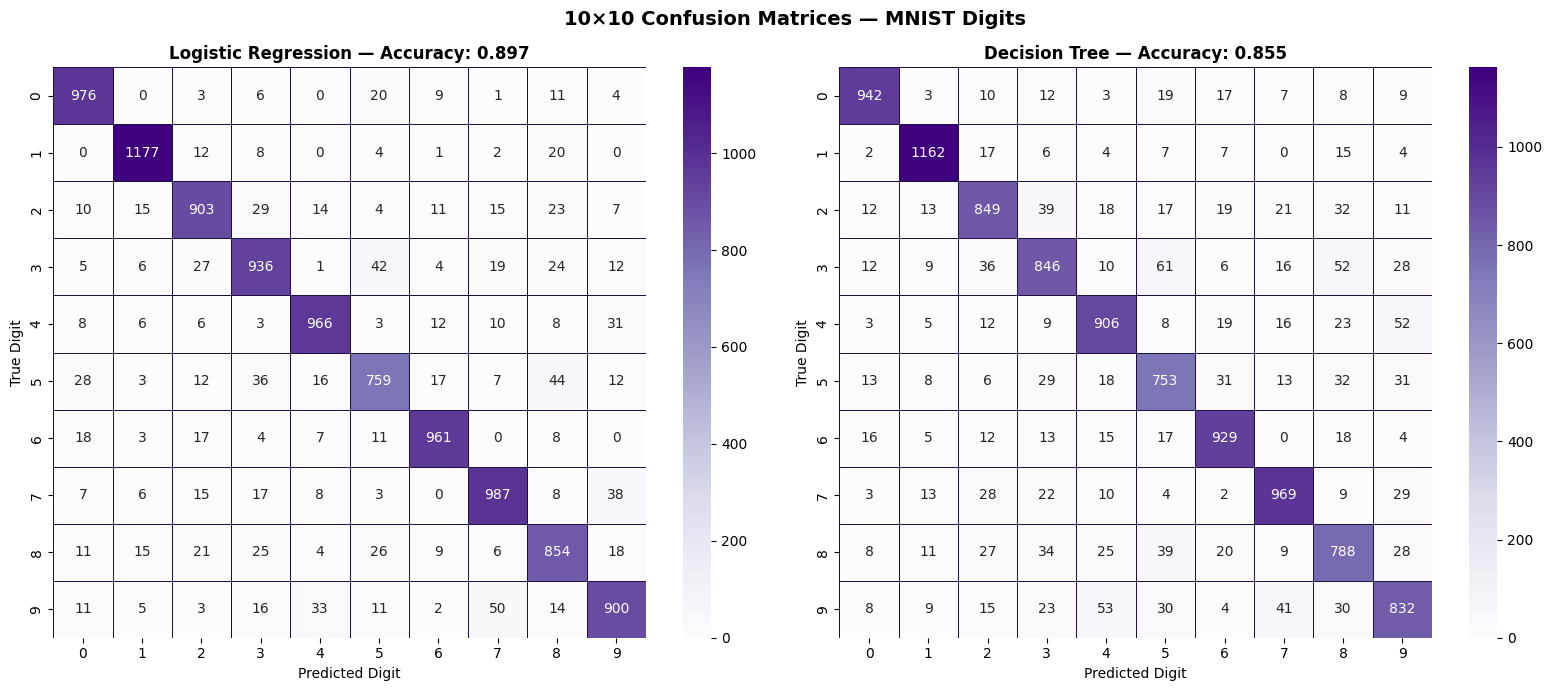

In [14]:
# Heatmap confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('10×10 Confusion Matrices — MNIST Digits', fontsize=14, fontweight='bold')

for ax, y_pred, title, acc in zip(
    axes,
    [y_pred3, y_pred4],
    ['Logistic Regression', 'Decision Tree'],
    [accuracy_score(y_test1, y_pred3), accuracy_score(y_test1, y_pred4)]
):
    cm = confusion_matrix(y_test1, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=range(10), yticklabels=range(10),
                linewidths=0.5, linecolor='#1e1040')
    ax.set_title(f'{title} — Accuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Digit', fontsize=10)
    ax.set_ylabel('True Digit', fontsize=10)

plt.tight_layout()
plt.show()

<div style="background: #0d0d20; border-left: 4px solid #a78bfa; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #a89dd0;">
  <strong style="color: #e2e0f0;">🔍 Reading the heatmap:</strong> Dark diagonal cells = correct predictions. Any bright off-diagonal cell is a common confusion. For example, <strong>8 vs 9</strong> and <strong>4 vs 9</strong> are typical digit pairs that get confused because they look similar visually.
</div>

<a id='report'></a>
<div style="border-bottom: 2px solid #7c3aed; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #7c3aed; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #e2e0f0; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Classification Report — All Metrics at Once</h2>
</div>

`classification_report` prints Precision, Recall, and F1 for every class simultaneously — the fastest way to get a complete picture of model performance.

<div style="background: #0d0d20; border: 1px solid #2d2060; border-radius: 8px; padding: 12px 18px; margin: 14px 0; font-size: 13px; color: #a89dd0;">
  <strong style="color: #a78bfa;">📌 Reading the report:</strong>
  <ul style="margin: 6px 0 0 0; padding-left: 18px; line-height: 2;">
    <li><code>precision</code> — quality of positive predictions for that class</li>
    <li><code>recall</code> — fraction of actual instances of that class caught</li>
    <li><code>f1-score</code> — harmonic mean of the two</li>
    <li><code>support</code> — number of actual samples in that class (test set)</li>
    <li><code>macro avg</code> — simple average across all classes</li>
    <li><code>weighted avg</code> — average weighted by support count</li>
  </ul>
</div>

In [15]:
print("=" * 60)
print("  LOGISTIC REGRESSION — Classification Report (MNIST)")
print("=" * 60)
print(classification_report(y_test1, y_pred3))

print("=" * 60)
print("  DECISION TREE — Classification Report (MNIST)")
print("=" * 60)
print(classification_report(y_test1, y_pred4))

  LOGISTIC REGRESSION — Classification Report (MNIST)
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1030
           1       0.95      0.96      0.96      1224
           2       0.89      0.88      0.88      1031
           3       0.87      0.87      0.87      1076
           4       0.92      0.92      0.92      1053
           5       0.86      0.81      0.84       934
           6       0.94      0.93      0.94      1029
           7       0.90      0.91      0.90      1089
           8       0.84      0.86      0.85       989
           9       0.88      0.86      0.87      1045

    accuracy                           0.90     10500
   macro avg       0.90      0.89      0.90     10500
weighted avg       0.90      0.90      0.90     10500

  DECISION TREE — Classification Report (MNIST)
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1030
           1       0.94      0

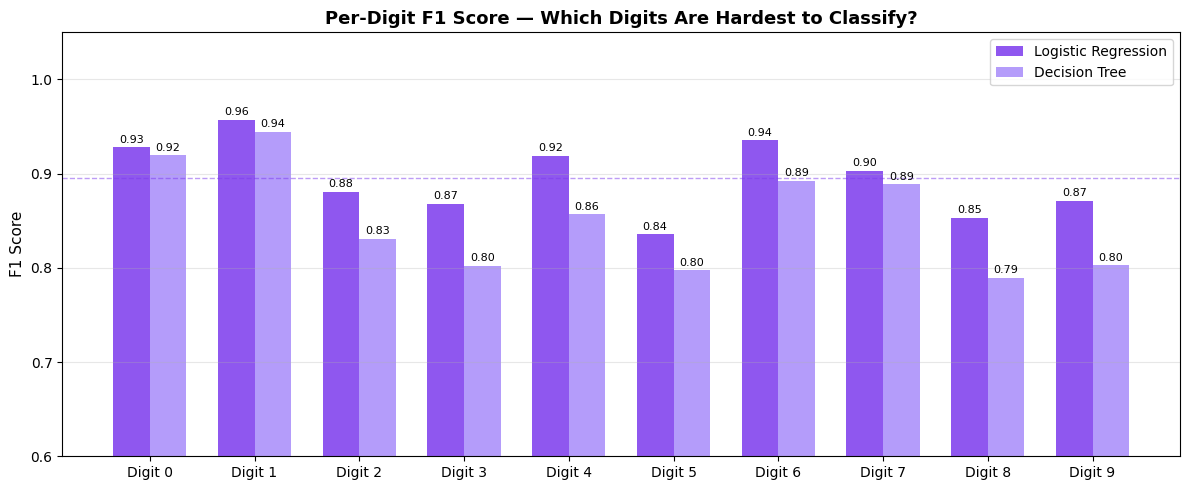

In [16]:
# Per-digit F1 bar chart — which digits are hardest to classify?
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test1, y_pred3, average=None)
f1_dt = f1_score(y_test1, y_pred4, average=None)

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, f1_lr, width, label='Logistic Regression', color='#7c3aed', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_dt, width, label='Decision Tree',       color='#a78bfa', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Digit {i}' for i in range(10)], fontsize=10)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0.6, 1.05)
ax.set_title('Per-Digit F1 Score — Which Digits Are Hardest to Classify?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt='%.2f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.2f', fontsize=8, padding=2)
ax.grid(axis='y', alpha=0.3)
ax.axhline(f1_lr.mean(), color='#7c3aed', linestyle='--', linewidth=1, alpha=0.5, label='LR mean')
plt.tight_layout()
plt.show()

<a id='summary'></a>
<div style="background: linear-gradient(135deg, #0a0a1a 0%, #1a1035 100%); border: 1px solid #2d2060; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary — When to Use Each Metric</h2>
  <p style="color: #a89dd0; font-size: 13px; margin: 0 0 20px 0;">Choose your metric based on what kind of error matters most in your domain.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(124,58,237,0.08); border: 1px solid #7c3aed; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a78bfa; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📊 Accuracy</div>
      <div style="color: #a89dd0; font-size: 12px; line-height: 1.7;">Use only when classes are balanced and errors are equally costly. <strong style='color:#e2e0f0;'>Default metric but often misleading.</strong> Never use alone on imbalanced data.</div>
    </div>
    <div style="background: rgba(124,58,237,0.08); border: 1px solid #7c3aed; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a78bfa; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🎯 Precision</div>
      <div style="color: #a89dd0; font-size: 12px; line-height: 1.7;">Use when <strong style='color:#e2e0f0;'>False Positives are costly</strong>. Spam filter (don't block good emails), recommendation systems (don't recommend bad items).</div>
    </div>
    <div style="background: rgba(124,58,237,0.08); border: 1px solid #7c3aed; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a78bfa; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔍 Recall</div>
      <div style="color: #a89dd0; font-size: 12px; line-height: 1.7;">Use when <strong style='color:#e2e0f0;'>False Negatives are costly</strong>. Disease detection (don't miss sick patients), fraud detection (don't miss fraudulent transactions).</div>
    </div>
    <div style="background: rgba(124,58,237,0.08); border: 1px solid #7c3aed; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a78bfa; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚖️ F1 Score</div>
      <div style="color: #a89dd0; font-size: 12px; line-height: 1.7;">Use when you need to <strong style='color:#e2e0f0;'>balance both Precision and Recall</strong> — imbalanced datasets where both error types matter. Best single metric for most real-world tasks.</div>
    </div>
  </div>
  <div style="background: rgba(255,255,255,0.03); border: 1px solid #2d2060; border-radius: 8px; padding: 14px 20px; margin-bottom: 16px; font-size: 13px; color: #a89dd0;">
    <strong style="color: #a78bfa;">🏥 This episode's domain (Heart Disease):</strong> <span style="color: #e2e0f0;">Recall is king</span> — missing a sick patient is far worse than a false alarm. Logistic Regression's Recall of 0.927 vs Decision Tree's 0.756 is the decisive difference — accuracy alone (89% vs 78%) understates how much better LR really is.
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #2d2060; color: #a89dd0; font-size: 12px;">
    Next up → <a href='https://www.kaggle.com/code/ahmedfakhar123/ml-40-roc-curve-auc-threshold-tuning' style='text-decoration: none;'><strong style='color:#a78bfa;'>ML 40: ROC Curve, AUC &amp; Threshold Tuning</strong></a> — visualising the Precision-Recall tradeoff across all decision thresholds.
  </div>
</div>